## Import

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import numpy as np
import scipy.linalg as linalg
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
#import preprocess


device = 'cuda:0'

%load_ext autoreload
%autoreload 2

## Data generation

In [2]:
from datasets import NonlinearGaussian, MoG

n, d = 10000, 64                                 # < higher d, higher MI
true_rho = 0.7                                   # < higher rho, higher MI
case = '3a'                                      # < choose between ['1a', '1b', '2', '3a', '3b', '3c', 'MoG']

if case != 'MoG':
    dataset = NonlinearGaussian.NonlinearGaussian(n_samples=n, n_dims=d, rho=true_rho, mu=0, case=case)
    X0, Y0 = dataset.sample_data(n_samples = n)
    X, Y = dataset.transformation(X0, Y0)
    MI = dataset.true_mutual_info()              # we know GT MI
else:
    dataset = MoG.MoG(n_samples=n, n_dims=d, K=5, shifts=[-0.4, -0.1, 0, 0.1, 0.4], rhos=[0.5, 0.6, 0.7, 0.8, 0.9])
    X, Y = dataset.sample_data(n_samples = n)
    MI = dataset.empirical_mutual_info()         # MI by MC estimate

X, Y = X.to(device), Y.to(device)
Z = torch.cat([X, Y], dim=1)
T = torch.ones(n, 2).to(device)

print('X size=', X.size(), 'Y size=', Y.size())
print("True MI is", MI)

X size= torch.Size([10000, 32]) Y size= torch.Size([10000, 32])
True MI is 10.77351285222025


## Train the VCE estimator

In [3]:
class Hyperparams(object):
    def __init__(self): 
        self.critic = 'neural'                # ('neural', 'quadratic')
        self.lr = 5e-4
        self.bs = 500
        self.n_bridges = 4
        self.wd = 1e-5
        self.max_iteration = 1250
        
hyperparams=Hyperparams()

architecture_critic = [d, 500, 500, 500, 1]

In [4]:
## Neural adaptive MI estimate
from estimators.VCE import VCE

estimator = VCE(None, None, architecture_critic, hyperparams)
estimator.to(device)
estimator.learn(X, Y)

print('true MI:', MI)
print('est MI:', estimator.MI(X, Y))

K components= 5 copula transform= True
nde type: FM
finished: t= 0 loss= 1.0538140535354614 loss val= 1.0451642274856567 best val loss= 1.0451642274856567 best t= 0
finished: t= 126 loss= 0.19917692244052887 loss val= 0.2044162154197693 best val loss= 0.1879328042268753 best t= 121
finished: t= 252 loss= 0.21743342280387878 loss val= 0.19357748329639435 best val loss= 0.18050207197666168 best t= 230
finished: t= 378 loss= 0.18063123524188995 loss val= 0.18410329520702362 best val loss= 0.1794739067554474 best t= 376
finished: t= 504 loss= 0.18134668469429016 loss val= 0.18550363183021545 best val loss= 0.1794341802597046 best t= 388
finished: t= 630 loss= 0.17611713707447052 loss val= 0.18992647528648376 best val loss= 0.17577522993087769 best t= 599
finished: t= 756 loss= 0.19424407184123993 loss val= 0.1821872591972351 best val loss= 0.17577522993087769 best t= 599


finished: t= 0 loss= 6.622068405151367 loss val= 6.526995658874512 best val loss= 6.526995658874512 best t= 0
finished

### Check the computed vector ranks

In [40]:
import torch.distributions as distribution

# XX, YY = estimator.forward(X, Y)

# Compute empirical ranks
sorted_data, idx = torch.sort(XX, dim=0)
_, idx2 = torch.sort(idx, dim=0)
U = (idx2.float()+1)/(len(XX)+1)   

# Compute covariance
zeros, ones = torch.zeros(XX.size()).to(XX.device), torch.ones(XX.size()).to(XX.device)
normal = distribution.Normal(zeros, ones)
XX_true = normal.icdf(U)
V = torch.matmul(XX_true.t(), XX_true)/(len(XX_true)+1)

### Visualizing the distributions of non-diagonal elements

mean abs 0.06455453928109024
q5 -0.10438685119152069
q95 0.10975728183984756


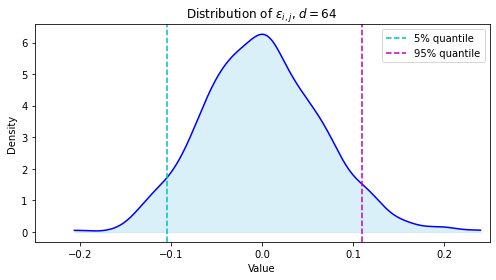

In [51]:
from scipy.stats import gaussian_kde


# Get non-diagonal elements of covariance matrices
non_diag_mask = ~torch.eye(V.size(0), dtype=bool, device=V.device)
non_diag_values = V[non_diag_mask]

# Convert to numpy
non_diag_np = non_diag_values.cpu().numpy()
sorted_vals = np.sort(non_diag_np)

# Compute ranks
L = len(sorted_vals)
q5, q95 = sorted_vals[int(L * 0.05)], sorted_vals[int(L * 0.95)]
print('mean abs', (sorted_vals**2).mean()**0.5)
print('q5', q5.item())
print('q95', q95.item())

# KDE with scipy
kde = gaussian_kde(non_diag_np)
x_vals = np.linspace(min(non_diag_np), max(non_diag_np), 1000)
density = kde(x_vals)

# Plot
plt.figure(figsize=(7, 4))
plt.plot(x_vals, density, color='blue')
plt.fill_between(x_vals, density, alpha=0.3, color='skyblue')
plt.axvline(q5, color='c', linestyle='--', label='5% quantile')
plt.axvline(q95, color='m', linestyle='--', label='95% quantile')
plt.title(r'Distribution of $\epsilon_{i, j}$, $d=64$')
plt.xlim(-0.25, 0.25)
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()